In [1]:
# import libraries 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy import stats


df = pd.read_csv('workflow_cleaned.csv')
# Convert date columns back to datetime
df['Task_Start_Time'] = pd.to_datetime(df['Task_Start_Time'])
df['Task_End_Time'] = pd.to_datetime(df['Task_End_Time'])



In [2]:
# 1. Descriptive statistics 

df.describe(include='all')
 

,Workflow_ID,Process_Name,Task_ID,Task_Type,Priority_Level,Department,Assigned_Employee_ID,Task_Start_Time,Task_End_Time,Estimated_Time_Minutes,Actual_Time_Minutes,Delay_Flag,Approval_Level,Employee_Workload,Cost_Per_Task
count,2500,2500,2500,2500,2500,2500,2500,2500,2500,2500.000000,2500.000000,2500.000000,2500,2500.000000,2500.000000
unique,2500,5,2500,5,4,5,150,NaN,NaN,NaN,NaN,NaN,3,NaN,NaN
top,WF_2500,Purchase Order,TASK_2500,Review,Low,Operations,EMP_28,NaN,NaN,NaN,NaN,NaN,Level 3,NaN,NaN
freq,1,517,1,530,663,505,30,NaN,NaN,NaN,NaN,NaN,853,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-06-29 12:57:07.512000,2024-06-29 15:57:59.352000,123.910000,180.864000,0.949200,NaN,5.520400,277.976708
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-01-01 02:40:00,2024-01-01 05:24:00,10.000000,7.000000,0.000000,NaN,1.000000,50.320000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-03-27 14:20:15,2024-03-27 18:14:15,67.000000,123.000000,1.000000,NaN,3.000000,164.162500
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-06-29 23:20:30,2024-06-30 02:33:30,121.000000,180.000000,1.000000,NaN,6.000000,279.355000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-09-27 01:32:00,2024-09-27 04:50:00,181.000000,238.250000,1.000000,NaN,8.000000,388.007500
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-12-30 23:07:00,2024-12-31 02:04:00,240.000000,357.000000,1.000000,NaN,10.000000,499.940000


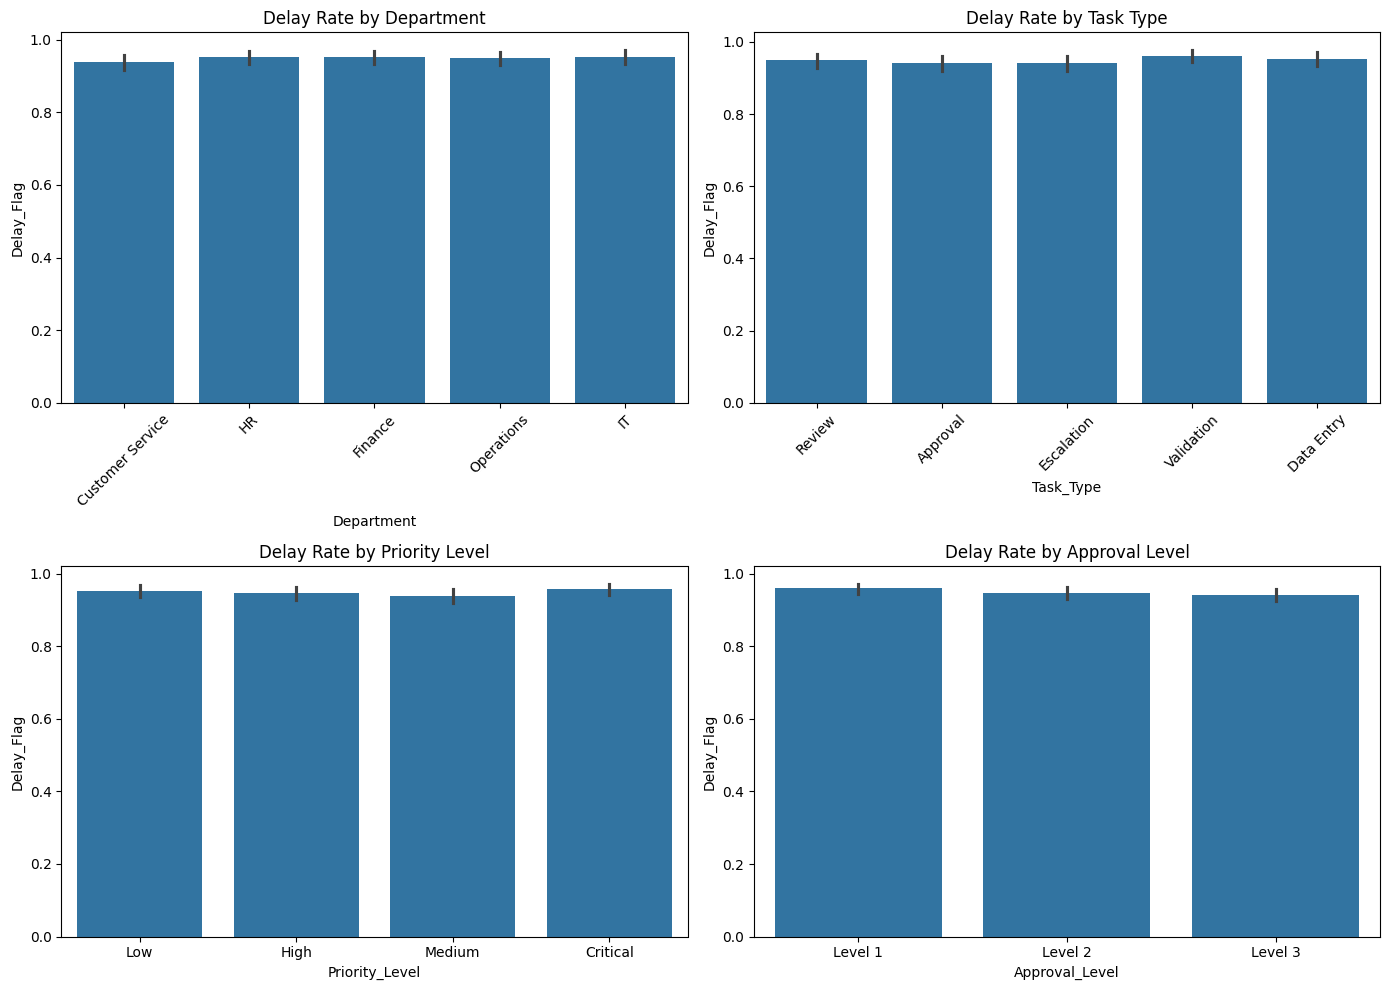

In [3]:
# 2. Delay rate by categorical variables

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.barplot(x='Department', y='Delay_Flag', data=df, ax=axes[0,0])
axes[0,0].set_title('Delay Rate by Department')
axes[0,0].tick_params(axis='x', rotation=45)

sns.barplot(x='Task_Type', y='Delay_Flag', data=df, ax=axes[0,1])
axes[0,1].set_title('Delay Rate by Task Type')
axes[0,1].tick_params(axis='x', rotation=45)

sns.barplot(x='Priority_Level', y='Delay_Flag', data=df, ax=axes[1,0])
axes[1,0].set_title('Delay Rate by Priority Level')

sns.barplot(x='Approval_Level', y='Delay_Flag', data=df, ax=axes[1,1])
axes[1,1].set_title('Delay Rate by Approval Level')
plt.tight_layout()
plt.show()
 


C:\Users\phill\AppData\Local\Temp\ipykernel_30900\3362358021.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  workload_impact = df.groupby('workload_bin')[['Delay_Flag', 'Actual_Time_Minutes', 'Cost_Per_Task']].mean()


Workload Impact:
               Delay_Flag  Actual_Time_Minutes  Cost_Per_Task
workload_bin                                                
0-2             0.958506           178.456432     269.793029
3-4             0.948980           184.571429     283.721776
5-6             0.945180           180.616257     278.324291
7-8             0.950690           182.013807     283.364852
9-10            0.943089           178.611789     274.346199


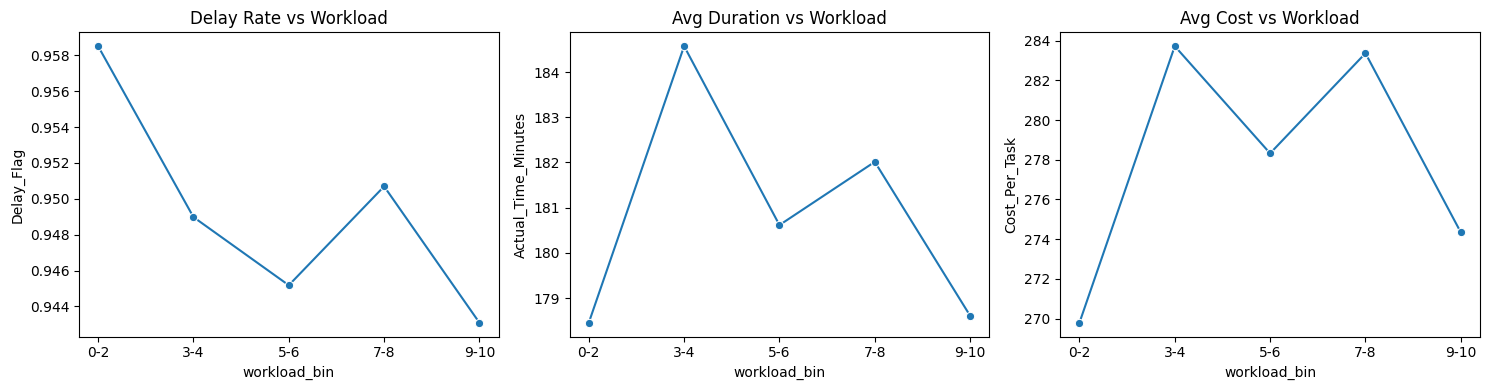

In [4]:
# 3. Employee Workload Impact 

# Bin workload into categories
df['workload_bin'] = pd.cut(df['Employee_Workload'], bins=[0,2,4,6,8,10], labels=['0-2','3-4','5-6','7-8','9-10'])
workload_impact = df.groupby('workload_bin')[['Delay_Flag', 'Actual_Time_Minutes', 'Cost_Per_Task']].mean()
print("Workload Impact:\n", workload_impact)

fig, axes = plt.subplots(1, 3, figsize=(15,4))
sns.lineplot(x=workload_impact.index, y='Delay_Flag', data=workload_impact, marker='o', ax=axes[0])
axes[0].set_title('Delay Rate vs Workload')
sns.lineplot(x=workload_impact.index, y='Actual_Time_Minutes', data=workload_impact, marker='o', ax=axes[1])
axes[1].set_title('Avg Duration vs Workload')
sns.lineplot(x=workload_impact.index, y='Cost_Per_Task', data=workload_impact, marker='o', ax=axes[2])
axes[2].set_title('Avg Cost vs Workload')
plt.tight_layout()
plt.show()


In [5]:
# 4. Bottleneck Detection 

# Departments with highest delays
dept_delay = df.groupby('Department')['Delay_Flag'].mean().sort_values(ascending=False)
print("Top bottleneck departments:\n", dept_delay.head())

# Task types with highest delays
tasktype_delay = df.groupby('Task_Type')['Delay_Flag'].mean().sort_values(ascending=False)
print("\nTop bottleneck task types:\n", tasktype_delay)

# Approval levels
applevel_delay = df.groupby('Approval_Level')['Delay_Flag'].mean().sort_values(ascending=False)
print("\nApproval level delay rates:\n", applevel_delay)


Top bottleneck departments:
 Department
IT                  0.953722
Finance             0.952381
HR                  0.952191
Operations          0.948515
Customer Service    0.939024
Name: Delay_Flag, dtype: float64

Top bottleneck task types:
 Task_Type
Validation    0.961460
Data Entry    0.952083
Review        0.949057
Escalation    0.942460
Approval      0.941176
Name: Delay_Flag, dtype: float64

Approval level delay rates:
 Approval_Level
Level 1    0.960048
Level 2    0.946407
Level 3    0.941383
Name: Delay_Flag, dtype: float64


In [6]:
# 5. Process Efficiency Comparison 

process_metrics = df.groupby('Process_Name').agg({
    'Estimated_Time_Minutes': 'mean',
    'Actual_Time_Minutes': 'mean',
    'Delay_Flag': 'mean',
    'Cost_Per_Task': 'mean'
}).round(2)
process_metrics['efficiency_ratio'] = (process_metrics['Actual_Time_Minutes'] / process_metrics['Estimated_Time_Minutes']).round(2)
process_metrics = process_metrics.sort_values('efficiency_ratio', ascending=False)
print("Process efficiency (higher ratio = worse):\n", process_metrics)



Process efficiency (higher ratio = worse):
                     Estimated_Time_Minutes  Actual_Time_Minutes  Delay_Flag  \
Process_Name                                                                  
Purchase Order                      122.82               180.33        0.95   
Invoice Approval                    122.57               180.44        0.96   
IT Support Ticket                   125.34               182.59        0.94   
HR Onboarding                       120.36               175.40        0.94   
Customer Complaint                  128.53               185.69        0.95   

                    Cost_Per_Task  efficiency_ratio  
Process_Name                                         
Purchase Order             281.42              1.47  
Invoice Approval           285.02              1.47  
IT Support Ticket          279.69              1.46  
HR Onboarding              270.28              1.46  
Customer Complaint         273.83              1.44  


In [7]:
# 6. Task Priority Effect 


priority_metrics = df.groupby('Priority_Level').agg({
    'Delay_Flag': 'mean',
    'Actual_Time_Minutes': 'mean',
    'Cost_Per_Task': 'mean'
}).round(2)
print("Priority effect:\n", priority_metrics)


Priority effect:
                 Delay_Flag  Actual_Time_Minutes  Cost_Per_Task
Priority_Level                                                
Critical              0.96               179.20         283.34
High                  0.95               179.78         286.72
Low                   0.95               183.59         267.59
Medium                0.94               180.74         274.60


In [8]:
# 7. Employee Performance Analysis

employee_perf = df.groupby('Assigned_Employee_ID').agg({
    'Delay_Flag': 'mean',
    'Actual_Time_Minutes': 'mean',
    'Cost_Per_Task': 'mean',
    'Task_ID': 'count'
}).rename(columns={'Task_ID': 'task_count'}).round(2)
employee_perf = employee_perf[employee_perf['task_count'] >= 5]  # only employees with sufficient tasks
employee_perf = employee_perf.sort_values('Delay_Flag')
print("Top 10 best performers (lowest delay rate):\n", employee_perf.head(10))
print("\nTop 10 worst performers (highest delay rate):\n", employee_perf.tail(10))


Top 10 best performers (lowest delay rate):
                       Delay_Flag  Actual_Time_Minutes  Cost_Per_Task  \
Assigned_Employee_ID                                                   
EMP_103                     0.75               205.88         319.83   
EMP_46                      0.79               218.36         251.22   
EMP_95                      0.80               199.10         266.91   
EMP_89                      0.81               193.94         342.88   
EMP_99                      0.82               176.53         254.25   
EMP_70                      0.83               184.78         307.64   
EMP_49                      0.86               201.43         253.31   
EMP_139                     0.86               171.57         347.95   
EMP_136                     0.86               171.21         279.50   
EMP_61                      0.86               162.41         237.36   

                      task_count  
Assigned_Employee_ID              
EMP_103             

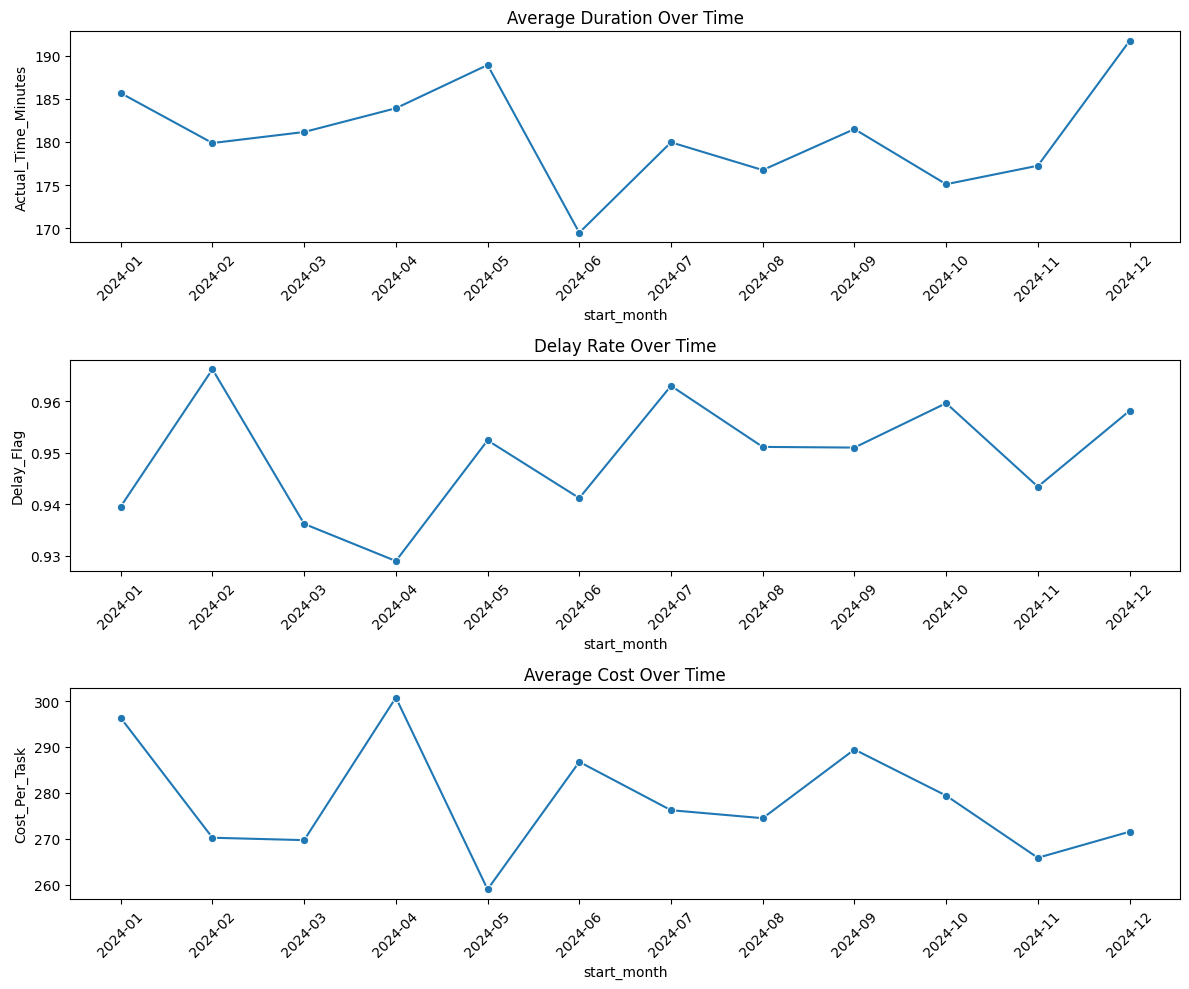

In [9]:
# 8. Time Series Analysis 

# Extract temporal features
df['start_date'] = df['Task_Start_Time'].dt.date
df['start_month'] = df['Task_Start_Time'].dt.to_period('M')
monthly_trends = df.groupby('start_month').agg({
    'Actual_Time_Minutes': 'mean',
    'Delay_Flag': 'mean',
    'Cost_Per_Task': 'mean'
}).reset_index()
monthly_trends['start_month'] = monthly_trends['start_month'].astype(str)

fig, axes = plt.subplots(3, 1, figsize=(12, 10))
sns.lineplot(x='start_month', y='Actual_Time_Minutes', data=monthly_trends, marker='o', ax=axes[0])
axes[0].set_title('Average Duration Over Time')
axes[0].tick_params(axis='x', rotation=45)

sns.lineplot(x='start_month', y='Delay_Flag', data=monthly_trends, marker='o', ax=axes[1])
axes[1].set_title('Delay Rate Over Time')
axes[1].tick_params(axis='x', rotation=45)

sns.lineplot(x='start_month', y='Cost_Per_Task', data=monthly_trends, marker='o', ax=axes[2])
axes[2].set_title('Average Cost Over Time')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()
